In [1]:
import sys
sys.path.append('../../my_spatial_analyze')
from visualization import plot_grid
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import pandas as pd
sys.path.append('../../my_spatial_analyze/data_analyze/correlation_analysis')
import correlation_plots
import numpy as np
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


Initializing pandarallel...
INFO: Pandarallel will run on 12 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.


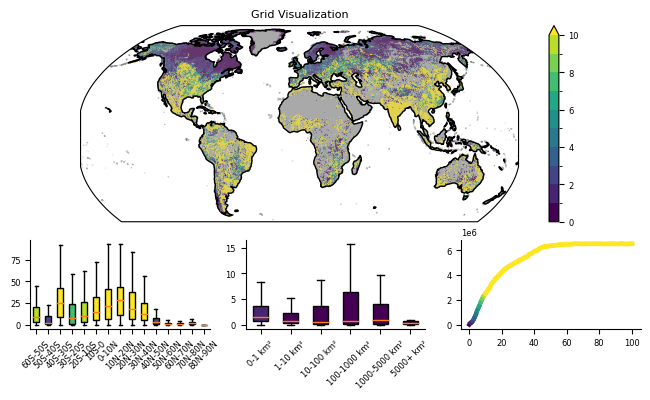

In [2]:
ax_mosaic = """
    aaa
    aaa
    bcd
"""

per_subplot_kw = {
    'a': {'projection': ccrs.Robinson()},
}

fig, axs = plt.subplot_mosaic(
    ax_mosaic,
    figsize=(200/25.4, 100/25.4),
    per_subplot_kw=per_subplot_kw
)

grid_pkl_path = '/data/v2/grid_all_medium_for_relative_to_total_area.pkl'
grid_gdf = pd.read_pickle(grid_pkl_path)
_, sm_of_total_variation_percentage = plot_grid(
    grid_gdf=grid_gdf.copy().to_crs(ccrs.Robinson()),
    projection=ccrs.Robinson(),
    save_path=None,
    color_column='total_variation_relative_to_total_area_median',
    gridlines=False,
    add_rivers=False,
    use_log_scale_color=False,
    set_global=False,
    extent=[-180, -60, 180, 90],
    use_discrete_color=True,
    discrete_bins=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    show=False,
    ax=axs['a'],
    draw_colorbar=True,
    return_colorbar_sm=True,
    cmap='viridis',
    cbar_extend='max'
)

lake_lse_pkl_path = '/data/v2/lake_lse_gdf_for_figure_making.pkl'
lake_lse_gdf = pd.read_pickle(lake_lse_pkl_path)

lat_column_name = 'Pour_lat'
lat_bins = [-60, -50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
lat_labels = ['60S-50S', '50S-40S', '40S-30S', '30S-20S', '20S-10S', '10S-0', '0-10N', '10N-20N', '20N-30N', '30N-40N', '40N-50N', '50N-60N', '60N-70N', '70N-80N', '80N-90N']
correlation_plots.box_plot_of_different_groups(
    to_plot_df=lake_lse_gdf,
    to_plot_column_name='total_variation_relative_to_total_area',
    to_group_by_column_name=lat_column_name,
    group_bins=lat_bins,
    group_labels=lat_labels,
    group_colors_box=sm_of_total_variation_percentage,
    ax=axs['b'],
    box_width=0.5,
    show_plot=False
)
axs['b'].spines['top'].set_visible(False)
axs['b'].spines['right'].set_visible(False)

del lake_lse_gdf
lake_lse_pkl_path = '/data/v2/lake_lse_gdf_for_figure_making.pkl'
lake_lse_gdf = pd.read_pickle(lake_lse_pkl_path)
lake_lse_gdf = lake_lse_gdf[(lake_lse_gdf['mean_area'] > 0)]
mean_area_column_name = 'mean_area'
mean_area_bins = [0, 1, 10, 100, 1000, 5000, np.inf]
mean_area_labels = ['0-1 km²', '1-10 km²', '10-100 km²', '100-1000 km²', '1000-5000 km²', '5000+ km²']
correlation_plots.box_plot_of_different_groups(
    to_plot_df=lake_lse_gdf,
    to_plot_column_name='total_variation_relative_to_total_area',
    to_group_by_column_name=mean_area_column_name,
    group_bins=mean_area_bins,
    group_labels=mean_area_labels,
    group_colors_box=sm_of_total_variation_percentage,
    ax=axs['c'],
    box_width=0.5,
    show_plot=False
)
axs['c'].spines['top'].set_visible(False)
axs['c'].spines['right'].set_visible(False)

basinatlas_pkl_path = '/data/v2/basinatlas_lev06_with_total_variation_relative_to_total_area_for_revision.pkl'
basinatlas_gdf = pd.read_pickle(basinatlas_pkl_path)
percentage_step = 0.5
percentage_ranges = np.arange(0, 101, percentage_step)
populations = []
for current_percentage in percentage_ranges:
    populations.append(basinatlas_gdf[basinatlas_gdf['total_variation_relative_to_total_area_median'] < current_percentage]['pop_ct_ssu'].sum())
for i in range(len(populations)-1):
    axs['d'].plot(percentage_ranges[i:i+2], populations[i:i+2], color=sm_of_total_variation_percentage.to_rgba(percentage_ranges[i]), linewidth=3)
#axs['d'].plot(percentage_ranges, populations, color='black')
#axs['d'].axvline(50, color='red', linestyle='--')
axs['d'].spines['top'].set_visible(False)
axs['d'].spines['right'].set_visible(False)

plt.savefig('/results/Ext_Data_Fig_4_raw.pdf', bbox_inches='tight')

In [1]:
print(lake_lse_gdf['total_variation_relative_to_total_area'].describe())

count    1.401566e+06
mean     5.248261e+00
std      1.230746e+01
min      0.000000e+00
25%      5.399494e-01
50%      1.280255e+00
75%      3.511771e+00
max      5.117330e+02
Name: total_variation_relative_to_total_area, dtype: float64
count    1.401802e+06
mean     1.833508e+00
std      1.608660e+02
min      3.000002e-02
25%      1.056422e-01
50%      1.950591e-01
75%      4.593562e-01
max      1.173345e+05
Name: lake_boundary_area_unbuffered, dtype: float64


KeyError: 'lake_type'